# Premier noteboook apprentissage profond

In [1]:
#on charge la clé API roboflow
#à mettre dans l'onglet 'Secrets' de colab
import os
ROBOFLOW_API_KEY = os.getenv('ROBOFLOW_API_KEY')

In [ ]:
#installer les dépendances
#!pip install -q gdown
#!pip install -q inference-gpu

#!pip install supervision==0.27.0
#!pip install -q git+https://github.com/roboflow/sports.git@feat/basketball

#!pip install -q transformers num2words
#!pip install -q flash-attn --no-build-isolation


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Cannot install inference-gpu==0.29.2, inference-gpu==0.30.0, inference-gpu==0.31.0, inference-gpu==0.31.1, inference-gpu==0.32.0, inference-gpu==0.33.0, inference-gpu==0.34.0, inference-gpu==0.35.0, inference-gpu==0.36.0, inference-gpu==0.36.1, inference-gpu==0.37.1, inference-gpu==0.38.0, inference-gpu==0.39.0, inference-gpu==0.40.0, inference-gpu==0.41.0, inference-gpu==0.42.1, inference-gpu==0.43.0, inference-gpu==0.44.0, inference-gpu==0.44.1, inference-gpu==0.45.0, inference-gpu==0.45.1, inference-gpu==0.45.2, inference-gpu==0.45.3, inference-gpu==0.46.0, inference-gpu==0.46.1, inference-gpu==0.46.3, inference-gpu==0.46.4, inference-gpu==0.46.5, inference-gpu==0.47.0, inference-gpu==0.48.0, inference-gpu==0.48.1, inference-gpu==0.48.3, inference-gpu==0.49.1, inference-gpu==0.49.2, inference-gpu==0.49.3, inference-gpu==0.49.5, inference-gpu==0.50.0, inference-gpu==0

In [ ]:
import os
#utiliser CUDA si disponible
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

In [ ]:
# pour télécharger quelques vidéos de basket NBA
#!gdown -q https://drive.google.com/drive/folders/1eDJYqQ77Fytz15tKGdJCMeYSgmoQ-2-H -O {SOURCE_VIDEO_DIRECTORY} --folder

In [8]:
SOURCE_VIDEO_PATH = "source/boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4"

In [ ]:
from IPython.display import Video
from typing import Dict, List, Optional, Union, Iterable, Tuple
from operator import itemgetter

import cv2
import numpy as np
import torch
from tqdm import tqdm

import base64
import cv2

#inference est la lib qui nous permet de charger et d'utiliser les modèles d'IA de roboflow
#supervision est la lib qui nous permet de faire du traitement vidéo et de l'affichage de résultats
#les 2 sont faits pour fonctionner ensemble de manière fluide et efficace

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_points_on_court,
    draw_paths_on_court,
    draw_made_and_miss_on_court,
    ShotEventTracker
)

In [ ]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
#on garde seulement les détections avec une confiance superieur à 40%
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4

#Intersection ov Union pour Non Maximum Suppresions. il faut que 2 bounding boxes se superposent à plus de 90% pour être considérées comme dupliquées.
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9

PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID, api_key=ROBOFLOW_API_KEY)

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

## Version originale basketball

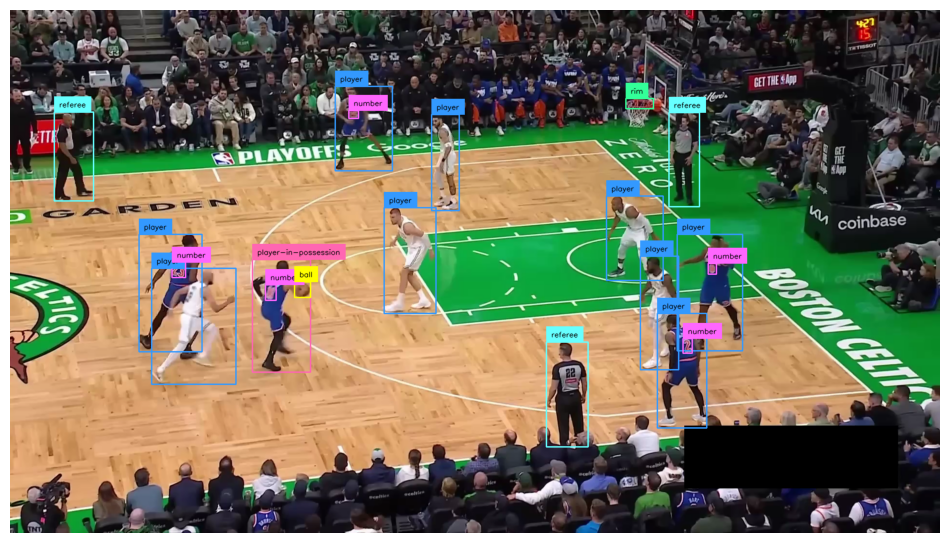

In [12]:
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

In [27]:
from pathlib import Path
SOURCE_VIDEO_PATH = Path(SOURCE_VIDEO_PATH)
TARGET_VIDEO_PATH = f"{SOURCE_VIDEO_PATH.stem}-detection{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = f"{Path(TARGET_VIDEO_PATH).stem}-detection{Path(TARGET_VIDEO_PATH).suffix}"

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result)

    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    return annotated_frame

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True
)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

Processing video: 100%|██████████| 238/238 [02:40<00:00,  1.48it/s]


## Version basket amateur

In [29]:
from pathlib import Path
SOURCE_VIDEO_PATH = "sample_data/NHL_vid.mp4"
SOURCE_VIDEO_PATH = Path(SOURCE_VIDEO_PATH)
TARGET_VIDEO_PATH = f"{SOURCE_VIDEO_PATH.stem}-detection{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = f"{Path(TARGET_VIDEO_PATH).stem}-detection{Path(TARGET_VIDEO_PATH).suffix}"

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result)

    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    return annotated_frame

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True
)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

Processing video: 100%|██████████| 600/600 [06:39<00:00,  1.50it/s]


In [15]:
# Version basket avec un match amateur
img_path = "sample_data/amateur.png"
with open(img_path, "rb") as f:
    img_base64 = base64.b64encode(f.read()).decode("utf-8")


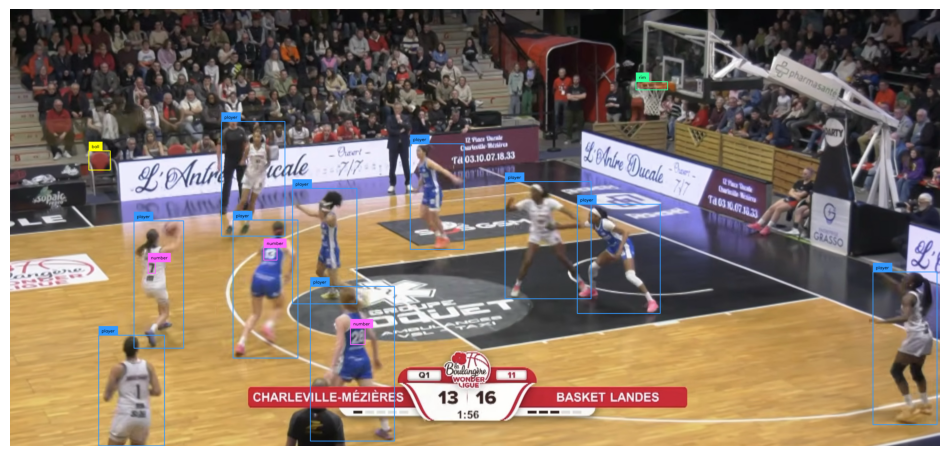

In [18]:
result = PLAYER_DETECTION_MODEL.infer(img_base64,
                                      confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
                                      iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)
detections = sv.Detections.from_inference(result[0])

image = cv2.imread(str(img_path))

annotated_frame = image.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

In [19]:
# Version basket avec un autre match amateur 
img_path = "sample_data/amateur2.png"
with open(img_path, "rb") as f:
    img_base64 = base64.b64encode(f.read()).decode("utf-8")

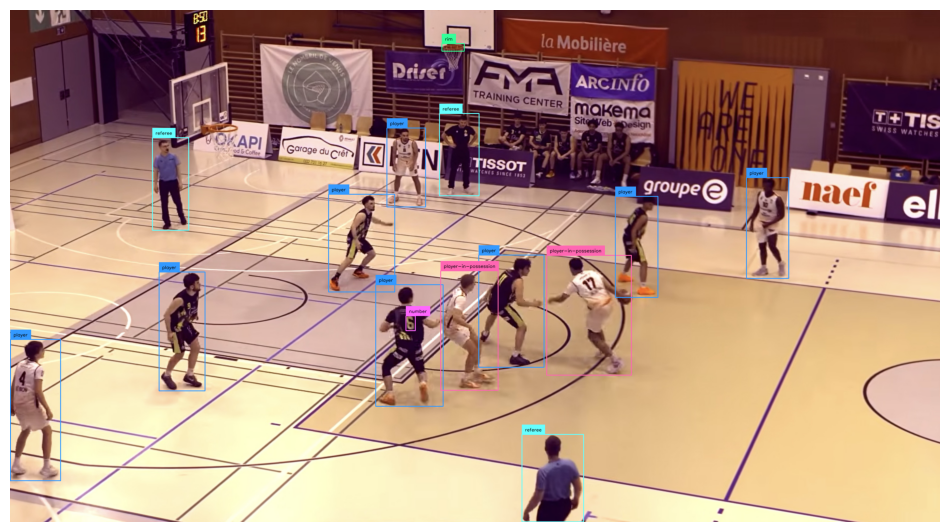

In [20]:
result = PLAYER_DETECTION_MODEL.infer(img_base64,
                                      confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
                                      iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)
detections = sv.Detections.from_inference(result[0])

image = cv2.imread(str(img_path))

annotated_frame = image.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

Trouver un moyen de limiter les "player in possession" à 1 seul

## Version Hockey

In [21]:
import base64

img_path = "sample_data/nhl.png"

with open(img_path, "rb") as f:
    img_base64 = base64.b64encode(f.read()).decode("utf-8")


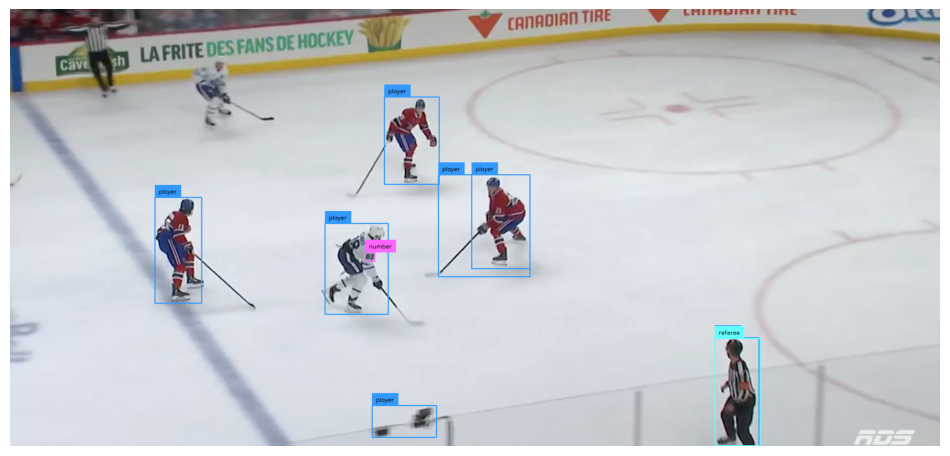

In [22]:
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(img_base64,
                                      confidence=PLAYER_DETECTION_MODEL_CONFIDENCE,
                                      iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)
detections = sv.Detections.from_inference(result[0])

image = cv2.imread(str(img_path))

annotated_frame = image.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

## Garder seulement les numéros

In [ ]:
NUMBER_CLASS_ID = 2

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == NUMBER_CLASS_ID]

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)